# Estimating the Effect of Job-Training Programs on Earnings
## Lalonde / Dehejia-Wahba Dataset — Causal Inference Analysis
**Author:** Joshua Carbajal | University of Chicago — Causal Models

---

This notebook was created with the aid of Claude

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import GradientBoostingClassifier, RandomForestRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import KFold
import xgboost as xgb
from econml.dml import CausalForestDML
import dowhy.datasets

plt.rcParams.update({'figure.dpi': 120, 'font.size': 11})

# RCT benchmark from Dehejia-Wahba 1999. This is the ATT (effect on those
# who actually received training) — all observational comparators below
# also report ATT for an apples-to-apples comparison.
RCT_BENCHMARK = 1794

# Includes u74, u75 (zero pre-earnings indicators) — Dehejia-Wahba (1999)
# canonical specification. These are the strongest non-linear discriminators
# between NSW (70%/60% zero pre-earners) and PSID-1 (8%/10%).
COVARIATES = ['age', 'educ', 'black', 'hisp', 'married', 'nodegree',
              're74', 're75', 'u74', 'u75']
TREATMENT = 'treat'
OUTCOME = 're78'

## 1. Load Data

Data loaded directly from the NBER source via `dowhy.datasets`.
- `lalonde_dataset()` — NSW RCT (treated + RCT controls)
- `psid_dataset()` — CPS-1 non-experimental comparison group

We combine the NSW treated participants with the CPS-1 controls to replicate
the hard observational estimation environment from Lalonde (1986).

In [2]:
# NSW RCT data (Dehejia-Wahba 1999 185/260 subset)
nsw = dowhy.datasets.lalonde_dataset()
nsw = nsw.rename(columns={'nodegr': 'nodegree'})
nsw['treat'] = nsw['treat'].astype(int)

# PSID-1 comparison group (mislabeled "CPS-1" historically; the loader
# actually returns the hardest of Dehejia-Wahba's three comparison groups).
cps1 = dowhy.datasets.psid_dataset()
cps1 = cps1.rename(columns={'nodegr': 'nodegree'})
cps1['treat'] = cps1['treat'].astype(int)

# Combine: NSW treated + PSID-1 controls (185 + 2,490 = 2,675; matches
# Dehejia-Wahba 1999 Table 1 exactly).
df = pd.concat([nsw[nsw['treat'] == 1], cps1], ignore_index=True)

# Zero pre-program earnings indicators — Dehejia-Wahba canonical covariates.
# dowhy's loaders usually add these; this is a defensive construction.
if 'u74' not in df.columns:
    df['u74'] = (df['re74'] == 0).astype(int)
if 'u75' not in df.columns:
    df['u75'] = (df['re75'] == 0).astype(int)

print(f"Combined sample: {len(df)} observations")
print(f"  Treated (NSW):       {df['treat'].sum()}")
print(f"  Controls (PSID-1):   {(df['treat'] == 0).sum()}")
print(f"  u74=1 share: treated={df.loc[df['treat']==1,'u74'].mean():.0%}  "
      f"control={df.loc[df['treat']==0,'u74'].mean():.0%}")
print(f"  u75=1 share: treated={df.loc[df['treat']==1,'u75'].mean():.0%}  "
      f"control={df.loc[df['treat']==0,'u75'].mean():.0%}")

Combined sample: 2675 observations
  Treated (NSW):       185
  Controls (PSID-1):   2490
  u74=1 share: treated=71%  control=9%
  u75=1 share: treated=60%  control=10%


## 2. Exploratory Data Analysis

In [3]:
# Group means
print("Means by group:")
df.groupby('treat')[COVARIATES + [OUTCOME]].mean().round(2)

Means by group:


,age,educ,black,hisp,married,nodegree,re74,re75,u74,u75,re78
treat,,,,,,,,,,,
0,34.85,12.12,0.25,0.03,0.87,0.31,19428.75,19063.34,0.09,0.1,21553.92
1,25.82,10.35,0.84,0.06,0.19,0.71,2095.57,1532.06,0.71,0.6,6349.14


In [4]:
# Standardized mean differences
def smd_unweighted(col, data):
    t = data.loc[data[TREATMENT] == 1, col]
    c = data.loc[data[TREATMENT] == 0, col]
    pooled_sd = np.sqrt((t.var() + c.var()) / 2)
    return (t.mean() - c.mean()) / pooled_sd if pooled_sd > 0 else 0.0

smd_df = pd.DataFrame({
    'Treated Mean': df[df[TREATMENT]==1][COVARIATES].mean().round(1),
    'Control Mean':  df[df[TREATMENT]==0][COVARIATES].mean().round(1),
    'SMD':           [round(smd_unweighted(c, df), 3) for c in COVARIATES]
})
print("Standardized Mean Differences (before adjustment):")
print(smd_df.to_string())

Standardized Mean Differences (before adjustment):
          Treated Mean  Control Mean    SMD
age               25.8          34.9 -1.009
educ              10.3          12.1 -0.681
black              0.8           0.3  1.480
hisp               0.1           0.0  0.129
married            0.2           0.9 -1.842
nodegree           0.7           0.3  0.879
re74            2095.6       19428.7 -1.718
re75            1532.1       19063.3 -1.774
u74                0.7           0.1  1.642
u75                0.6           0.1  1.228


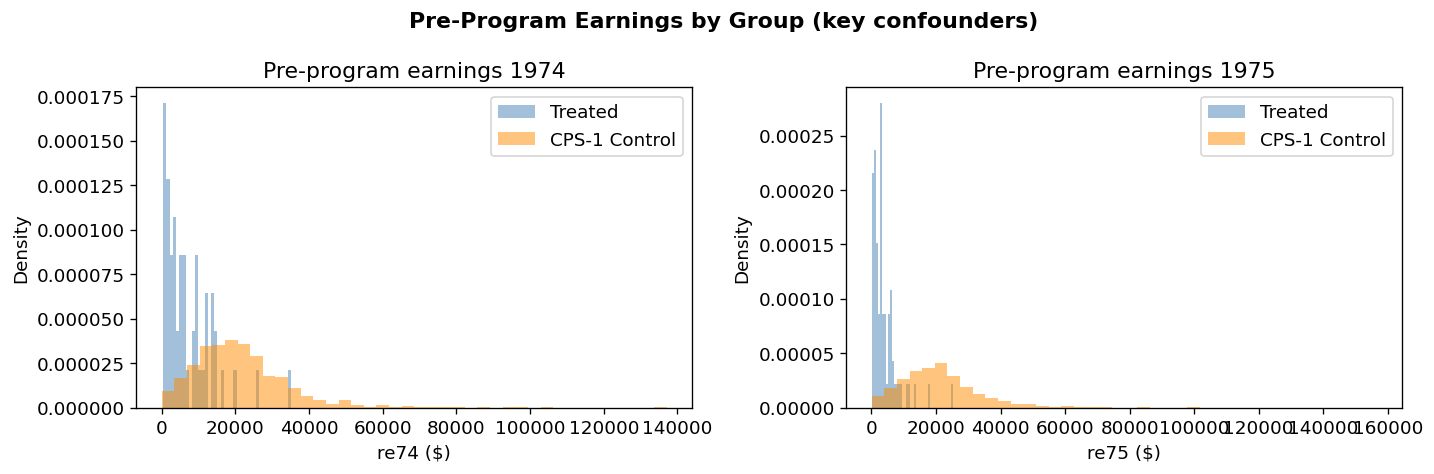

In [5]:
# Pre-program earnings distributions
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for ax, col, year in zip(axes, ['re74', 're75'], ['1974', '1975']):
    for grp, label, color in [(1, 'Treated', 'steelblue'), (0, 'CPS-1 Control', 'darkorange')]:
        vals = df.loc[(df[TREATMENT] == grp) & (df[col] > 0), col]
        ax.hist(vals, bins=40, alpha=0.5, color=color, density=True, label=label)
    ax.set_title(f'Pre-program earnings {year}')
    ax.set_xlabel(f're{year[-2:]} ($)')
    ax.set_ylabel('Density')
    ax.legend()
plt.suptitle('Pre-Program Earnings by Group (key confounders)', fontweight='bold')
plt.tight_layout()
plt.savefig('../outputs/eda_preearnings.png', bbox_inches='tight')
plt.show()

## 3. Method 1: Inverse Probability Weighting for the ATT

Reports the **ATT** — average effect on the treated — to match every published
NSW + PSID-1 comparator (Dehejia-Wahba 1999, Hirano-Imbens-Ridder 2003,
Smith-Todd 2005) and the RCT benchmark itself (which is also an ATT).

- **Propensity model**: gradient-boosted classifier (handles non-linearities
  and severe imbalance better than a linear logit).
- **Trim**: Crump et al. (2009) overlap rule, PS ∈ [0.10, 0.90]. The earlier
  1st/99th percentile rule was a no-op on the control side because PSID-1
  propensities cluster at ps < 0.01 (no left tail to chop).
- **Estimator**: Hájek-normalized IPW-ATT.
- **Bootstrap**: refits the propensity model on each draw to propagate PS
  estimation uncertainty into the CI.

In [6]:
X = df[COVARIATES].values
T = df[TREATMENT].values
Y = df[OUTCOME].values

# Gradient-boosted propensity (fix #6). Trees handle non-linearities and
# the u74·re74 interaction natively, no scaling needed.
ps_model = GradientBoostingClassifier(n_estimators=300, max_depth=3,
                                      learning_rate=0.05, subsample=0.8,
                                      random_state=42)
ps_model.fit(X, T)
ps = ps_model.predict_proba(X)[:, 1]

# Crump et al. (2009) overlap trim (fix #4): PS in [0.10, 0.90].
TRIM_LO, TRIM_HI = 0.10, 0.90
mask = (ps >= TRIM_LO) & (ps <= TRIM_HI)

T_t, Y_t, ps_t = T[mask], Y[mask], ps[mask]
X_t = X[mask]
df_t = df[mask].copy().reset_index(drop=True)
df_t['ps'] = ps_t

print(f"Crump-trimmed: dropped {(~mask).sum()} observations "
      f"({(~mask).mean():.1%}) outside [{TRIM_LO}, {TRIM_HI}].")
print(f"  Treated remaining:  {(T_t == 1).sum()}")
print(f"  Controls remaining: {(T_t == 0).sum()}")

Crump-trimmed: dropped 2523 observations (94.3%) outside [0.1, 0.9].
  Treated remaining:  87
  Controls remaining: 65


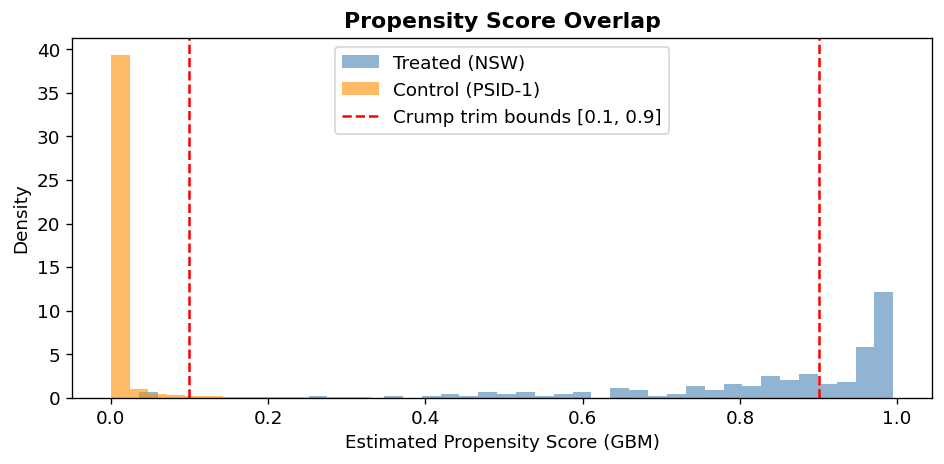

In [7]:
# Propensity score overlap plot
fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(ps[T==1], bins=40, alpha=0.6, color='steelblue', density=True, label='Treated (NSW)')
ax.hist(ps[T==0], bins=40, alpha=0.6, color='darkorange', density=True, label='Control (PSID-1)')
ax.axvline(TRIM_LO, color='red', linestyle='--', linewidth=1.5,
           label=f'Crump trim bounds [{TRIM_LO}, {TRIM_HI}]')
ax.axvline(TRIM_HI, color='red', linestyle='--', linewidth=1.5)
ax.set_xlabel('Estimated Propensity Score (GBM)')
ax.set_ylabel('Density')
ax.set_title('Propensity Score Overlap', fontweight='bold')
ax.legend()
plt.tight_layout()
plt.savefig('../outputs/ipw_overlap.png', bbox_inches='tight')
plt.show()

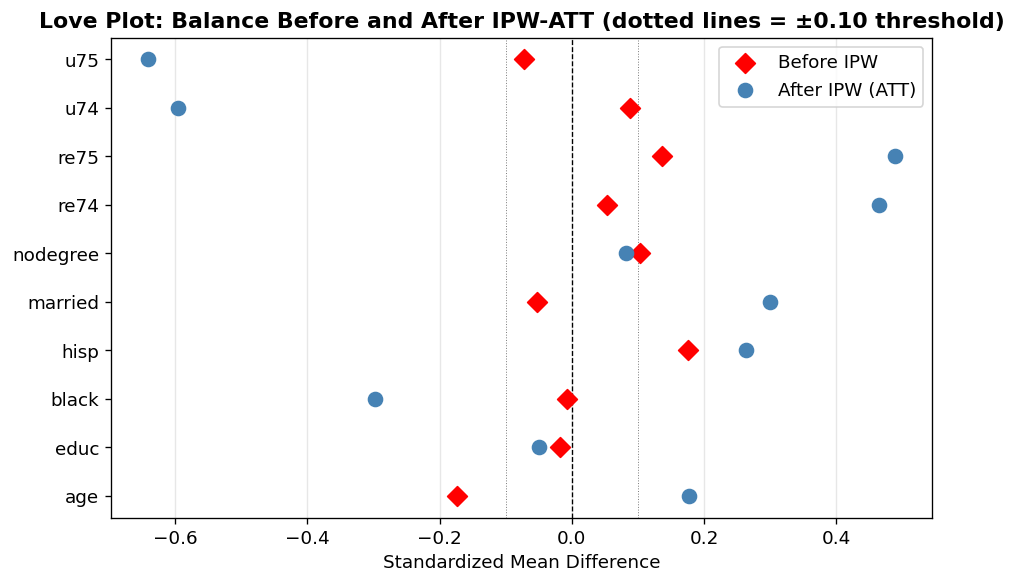

Post-weighting SMDs (ATT):
  age          +0.177  IMBALANCED
  educ         -0.050  OK
  black        -0.298  IMBALANCED
  hisp         +0.263  IMBALANCED
  married      +0.299  IMBALANCED
  nodegree     +0.082  OK
  re74         +0.464  IMBALANCED
  re75         +0.489  IMBALANCED
  u74          -0.595  IMBALANCED
  u75          -0.641  IMBALANCED


In [8]:
# ATT weights (fix #3): treated obs count as themselves, controls are
# reweighted by ps/(1-ps) to resemble the treated covariate distribution.
weights = np.where(T_t == 1, 1.0, ps_t / (1 - ps_t))
df_t['ipw_weight'] = weights

# Love plot — balance before and after ATT weighting
def smd_weighted(col, data, weight_col):
    t = data[data[TREATMENT] == 1]
    c = data[data[TREATMENT] == 0]
    t_mean = np.average(t[col], weights=t[weight_col])
    c_mean = np.average(c[col], weights=c[weight_col])
    pooled_sd = np.sqrt((data[data[TREATMENT]==1][col].var() +
                         data[data[TREATMENT]==0][col].var()) / 2)
    return (t_mean - c_mean) / pooled_sd if pooled_sd > 0 else 0.0

smd_before = [smd_unweighted(c, df_t) for c in COVARIATES]
smd_after  = [smd_weighted(c, df_t, 'ipw_weight') for c in COVARIATES]

fig, ax = plt.subplots(figsize=(8, 5))
y = np.arange(len(COVARIATES))
ax.scatter(smd_before, y, color='red',       marker='D', s=70, zorder=3, label='Before IPW')
ax.scatter(smd_after,  y, color='steelblue', marker='o', s=70, zorder=3, label='After IPW (ATT)')
ax.axvline(0,    color='black', linewidth=0.8, linestyle='--')
ax.axvline( 0.1, color='gray',  linewidth=0.6, linestyle=':')
ax.axvline(-0.1, color='gray',  linewidth=0.6, linestyle=':')
ax.set_yticks(y)
ax.set_yticklabels(COVARIATES)
ax.set_xlabel('Standardized Mean Difference')
ax.set_title('Love Plot: Balance Before and After IPW-ATT (dotted lines = ±0.10 threshold)',
             fontweight='bold')
ax.legend()
ax.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.savefig('../outputs/ipw_love_plot.png', bbox_inches='tight')
plt.show()

print("Post-weighting SMDs (ATT):")
for cov, after in zip(COVARIATES, smd_after):
    flag = "OK" if abs(after) < 0.10 else "IMBALANCED"
    print(f"  {cov:<12} {after:+.3f}  {flag}")

In [9]:
# IPW-ATT estimate with bootstrap CI (fix #3: ATT, fix #7: refit PS each draw)
def ipw_att(T, Y, ps):
    """Hájek-normalized IPW estimator for the ATT."""
    w0 = ps / (1 - ps)
    mu1 = (T * Y).sum() / T.sum()
    mu0 = ((1 - T) * w0 * Y).sum() / ((1 - T) * w0).sum()
    return mu1 - mu0

def fit_ps_and_att(X, T, Y, trim_lo=TRIM_LO, trim_hi=TRIM_HI, seed=0):
    """Refit PS on a bootstrap draw, apply Crump trim, compute ATT."""
    m = GradientBoostingClassifier(n_estimators=300, max_depth=3,
                                   learning_rate=0.05, subsample=0.8,
                                   random_state=seed)
    m.fit(X, T)
    ps_b = m.predict_proba(X)[:, 1]
    msk = (ps_b >= trim_lo) & (ps_b <= trim_hi)
    if msk.sum() < 50 or T[msk].sum() == 0 or (1 - T[msk]).sum() == 0:
        return np.nan
    return ipw_att(T[msk], Y[msk], ps_b[msk])

att_ipw = ipw_att(T_t, Y_t, ps_t)

# Bootstrap with PS refit each draw (fix #7).
print("Bootstrapping IPW-ATT (500 draws, refitting PS each time)...")
np.random.seed(42)
N = len(T)
boot_atts = []
for b in range(500):
    idx = np.random.choice(N, N, replace=True)
    a = fit_ps_and_att(X[idx], T[idx], Y[idx], seed=b)
    if not np.isnan(a):
        boot_atts.append(a)
    if (b + 1) % 100 == 0:
        print(f"  {b+1}/500 done")

boot_atts = np.array(boot_atts)
ipw_lo = np.percentile(boot_atts, 2.5)
ipw_hi = np.percentile(boot_atts, 97.5)

print(f"IPW-ATT:  ${att_ipw:,.0f}  (95% CI: ${ipw_lo:,.0f} to ${ipw_hi:,.0f})")
print(f"RCT benchmark (ATT): ${RCT_BENCHMARK:,}  |  Bias: ${att_ipw - RCT_BENCHMARK:+,.0f}")

Bootstrapping IPW-ATT (500 draws, refitting PS each time)...


  100/500 done


  200/500 done


  300/500 done


  400/500 done


  500/500 done
IPW-ATT:  $3,038  (95% CI: $-63 to $5,348)
RCT benchmark (ATT): $1,794  |  Bias: $+1,244


## 4. Method 2: Augmented IPW for the ATT (AIPW-ATT)

Doubly-robust estimator with cross-fitted nuisances. Reports the **ATT**
(matching IPW and the RCT benchmark).

Key implementation choices vs the original ATE-AIPW:
- **Estimand**: ATT, using the Imbens (2015) ATT-DR score. Only μ_0 is
  needed (no μ_1 model on the treated arm), eliminating the XGBoost-on-148
  extrapolation problem that dominated the previous estimate.
- **Trim**: Crump [0.10, 0.90] before estimation. Without trimming, the
  AIPW score sums over PSID rows where T=0 zeroes the DR correction term,
  silently degenerating into a pure outcome-regression contrast over a
  non-overlap region.
- **Propensity**: gradient-boosted classifier (same model class as cell 9).
- **Clip**: [0.05, 0.95] (tighter than the original [0.01, 0.99] floor,
  which permitted per-observation weights of ~100×).

In [10]:
# AIPW-ATT on the Crump-trimmed sample (X_t, T_t, Y_t from cell 9)
X_dr = X_t
T_dr = T_t.astype(float)
Y_dr = Y_t
n    = len(Y_dr)

K  = 5
kf = KFold(n_splits=K, shuffle=True, random_state=42)

mu0_hat = np.zeros(n)
ps_hat  = np.zeros(n)

xgb_params = dict(n_estimators=300, max_depth=5, learning_rate=0.05,
                  subsample=0.8, colsample_bytree=0.8, random_state=42, verbosity=0)

print(f"Running {K}-fold cross-fitting (AIPW-ATT, n={n})...")
for fold, (tr_idx, val_idx) in enumerate(kf.split(X_dr), 1):
    X_tr, X_val = X_dr[tr_idx], X_dr[val_idx]
    T_tr, Y_tr  = T_dr[tr_idx], Y_dr[tr_idx]

    # Propensity: GBM (fix #6; tree model, no scaling).
    ps_m = GradientBoostingClassifier(n_estimators=300, max_depth=3,
                                      learning_rate=0.05, subsample=0.8,
                                      random_state=42)
    ps_m.fit(X_tr, T_tr)
    ps_hat[val_idx] = ps_m.predict_proba(X_val)[:, 1]

    # ATT-AIPW only needs μ_0 — sidesteps the μ_1 extrapolation problem
    # that dominated the original ATE-AIPW on PSID rows.
    mu0_m = xgb.XGBRegressor(**xgb_params)
    mu0_m.fit(X_tr[T_tr == 0], Y_tr[T_tr == 0])
    mu0_hat[val_idx] = mu0_m.predict(X_val)

    print(f"  Fold {fold}/{K} done")

# ATT-AIPW score (efficient influence function for ATT; Hahn 1998, Imbens 2015 eq. 24).
ps_c = np.clip(ps_hat, 0.05, 0.95)   # fix #5: tighter clip than [0.01, 0.99]
p_T  = T_dr.mean()
phi  = (T_dr * (Y_dr - mu0_hat) / p_T
        - (1 - T_dr) * ps_c * (Y_dr - mu0_hat) / ((1 - ps_c) * p_T))

att_aipw = phi.mean()
se_aipw  = phi.std() / np.sqrt(n)
aipw_lo  = att_aipw - 1.96 * se_aipw
aipw_hi  = att_aipw + 1.96 * se_aipw

print(f"AIPW-ATT: ${att_aipw:,.0f}  (95% CI: ${aipw_lo:,.0f} to ${aipw_hi:,.0f})")
print(f"RCT benchmark (ATT): ${RCT_BENCHMARK:,}  |  Bias: ${att_aipw - RCT_BENCHMARK:+,.0f}")

Running 5-fold cross-fitting (AIPW-ATT, n=152)...


  Fold 1/5 done


  Fold 2/5 done


  Fold 3/5 done


  Fold 4/5 done


  Fold 5/5 done
AIPW-ATT: $2,824  (95% CI: $-4,436 to $10,083)
RCT benchmark (ATT): $1,794  |  Bias: $+1,030


## 5. Method 3: Causal Forest (ATT)

Implemented via econml's `CausalForestDML` aligned to grf defaults:
- `discrete_treatment=True` (fix #2) — the single most important change.
  econml's default is False, so a 0/1 treatment is residualized via
  least-squares regression; on a 7% positive class this collapses the
  T-residuals toward zero and pulls the ATE toward zero. grf always uses
  a probability forest for the treatment nuisance.
- `model_t = GradientBoostingClassifier` and `model_y = RandomForestRegressor`
  — replaces econml's `'auto'` selector (which would have chosen between
  RF and WeightedLassoCV via CV) with stable, defensible nuisances.
- `n_estimators=2000`, `min_samples_leaf=5` — grf defaults.
- Reports **ATT** by averaging CATE estimates over the treated covariate
  distribution only (matches IPW and AIPW).

In [11]:
X = df[COVARIATES].values
T = df[TREATMENT].values.astype(int)   # discrete: pass int, not float
Y = df[OUTCOME].values

print("Fitting Causal Forest (grf-aligned; this takes ~1-3 minutes)...")
cf = CausalForestDML(
    n_estimators=2000,                 # grf default (was 500)
    min_samples_leaf=5,                 # grf default (was 10)
    honest=True,
    inference=True,
    cv=5,
    discrete_treatment=True,           # fix #2: critical for binary T
    model_t=GradientBoostingClassifier(n_estimators=300, max_depth=3,
                                       learning_rate=0.05, subsample=0.8,
                                       random_state=42),
    model_y=RandomForestRegressor(n_estimators=500, min_samples_leaf=5,
                                  random_state=42, n_jobs=-1),
    random_state=42,
    n_jobs=-1,
)
cf.fit(Y, T, X=X)
print("Done.")

# Report ATT (average CATE over the treated covariate distribution) to match
# IPW and AIPW. Also keep ATE for reference.
X_treated = X[T == 1]

att_cf       = cf.ate(X_treated)
att_cf_lo, att_cf_hi = cf.ate_interval(X_treated, alpha=0.05)
ate_cf       = cf.ate(X)
cf_lo, cf_hi = cf.ate_interval(X, alpha=0.05)

print(f"Causal Forest ATT: ${att_cf:,.0f}  (95% CI: ${att_cf_lo:,.0f} to ${att_cf_hi:,.0f})")
print(f"Causal Forest ATE: ${ate_cf:,.0f}  (95% CI: ${cf_lo:,.0f} to ${cf_hi:,.0f})  [for reference]")
print(f"RCT benchmark (ATT): ${RCT_BENCHMARK:,}  |  ATT bias: ${att_cf - RCT_BENCHMARK:+,.0f}")

Fitting Causal Forest (grf-aligned; this takes ~1-3 minutes)...


Done.


Causal Forest ATT: $303  (95% CI: $-3,418 to $4,024)
Causal Forest ATE: $-51,573  (95% CI: $-779,528 to $676,383)  [for reference]
RCT benchmark (ATT): $1,794  |  ATT bias: $-1,491


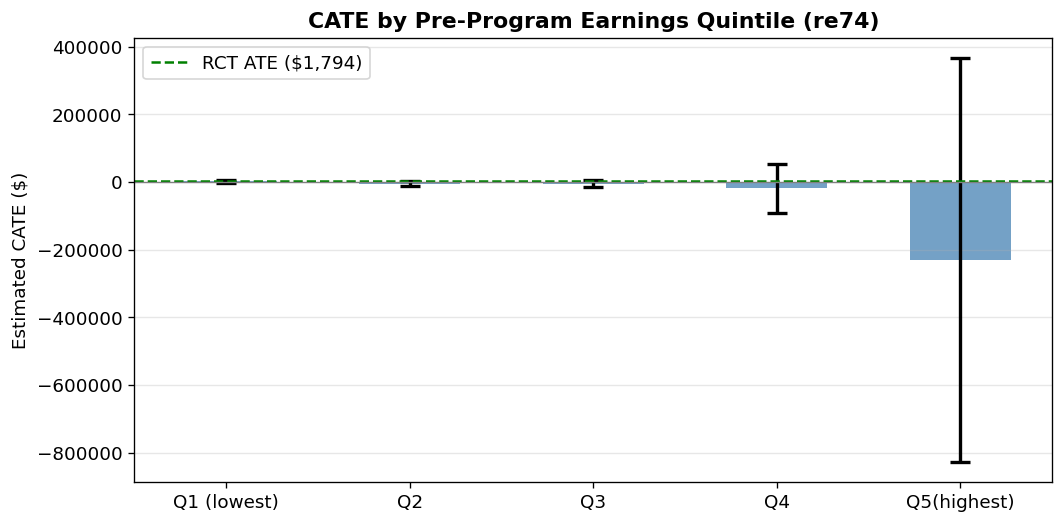

In [12]:
# Individual CATE estimates
cate              = cf.effect(X)
cate_lo, cate_hi  = cf.effect_interval(X, alpha=0.05)
df['cate']        = cate
df['cate_lo']     = cate_lo
df['cate_hi']     = cate_hi

# CATE by pre-program earnings quintile
df['re74_quintile'] = pd.qcut(df['re74'], q=5,
    labels=['Q1 (lowest)', 'Q2', 'Q3', 'Q4', 'Q5(highest)'])

q_stats = df.groupby('re74_quintile', observed=True).agg(
    cate_mean=('cate','mean'), cate_lo=('cate_lo','mean'), cate_hi=('cate_hi','mean')
).reset_index()

fig, ax = plt.subplots(figsize=(9, 4.5))
x = np.arange(len(q_stats))
ax.bar(x, q_stats['cate_mean'], color='steelblue', alpha=0.75, width=0.55)
ax.errorbar(x, q_stats['cate_mean'],
            yerr=[q_stats['cate_mean']-q_stats['cate_lo'],
                  q_stats['cate_hi']-q_stats['cate_mean']],
            fmt='none', color='black', capsize=6, capthick=2, elinewidth=2)
ax.axhline(RCT_BENCHMARK, color='green', linestyle='--', linewidth=1.5,
           label=f'RCT ATE (${RCT_BENCHMARK:,})')
ax.axhline(0, color='gray', linewidth=0.8)
ax.set_xticks(x); ax.set_xticklabels(q_stats['re74_quintile'])
ax.set_ylabel('Estimated CATE ($)')
ax.set_title('CATE by Pre-Program Earnings Quintile (re74)', fontweight='bold')
ax.legend(); ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('../outputs/cf_cate_quintile.png', bbox_inches='tight')
plt.show()

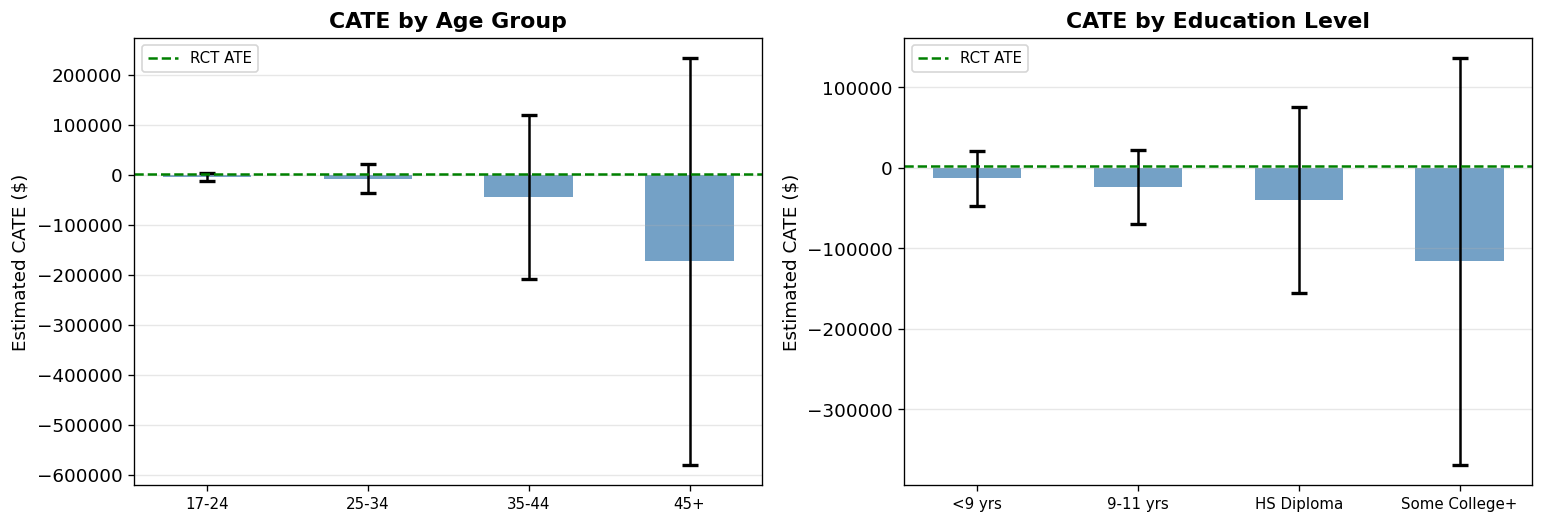

In [13]:
# CATE by age group and education level
df['age_group']  = pd.cut(df['age'],  bins=[16,24,34,44,65],
                           labels=['17-24','25-34','35-44','45+'])
df['educ_group'] = pd.cut(df['educ'], bins=[2,8,11,12,16],
                           labels=['<9 yrs','9-11 yrs','HS Diploma','Some College+'])

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
for ax, col, title in zip(axes, ['age_group','educ_group'], ['Age Group','Education Level']):
    stats = df.groupby(col, observed=True).agg(
        cate_mean=('cate','mean'), cate_lo=('cate_lo','mean'), cate_hi=('cate_hi','mean')
    ).reset_index()
    x = np.arange(len(stats))
    ax.bar(x, stats['cate_mean'], color='steelblue', alpha=0.75, width=0.55)
    ax.errorbar(x, stats['cate_mean'],
                yerr=[stats['cate_mean']-stats['cate_lo'],
                      stats['cate_hi']-stats['cate_mean']],
                fmt='none', color='black', capsize=5, capthick=2, elinewidth=1.5)
    ax.axhline(RCT_BENCHMARK, color='green', linestyle='--', linewidth=1.5, label='RCT ATE')
    ax.set_xticks(x); ax.set_xticklabels(stats[col], fontsize=9)
    ax.set_ylabel('Estimated CATE ($)')
    ax.set_title(f'CATE by {title}', fontweight='bold')
    ax.legend(fontsize=9); ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('../outputs/cf_cate_age_educ.png', bbox_inches='tight')
plt.show()

## 6. Results Comparison (ATT)

All three observational ATT estimates compared against the RCT-derived ATT
benchmark of ~$1,794 (Dehejia-Wahba 1999).

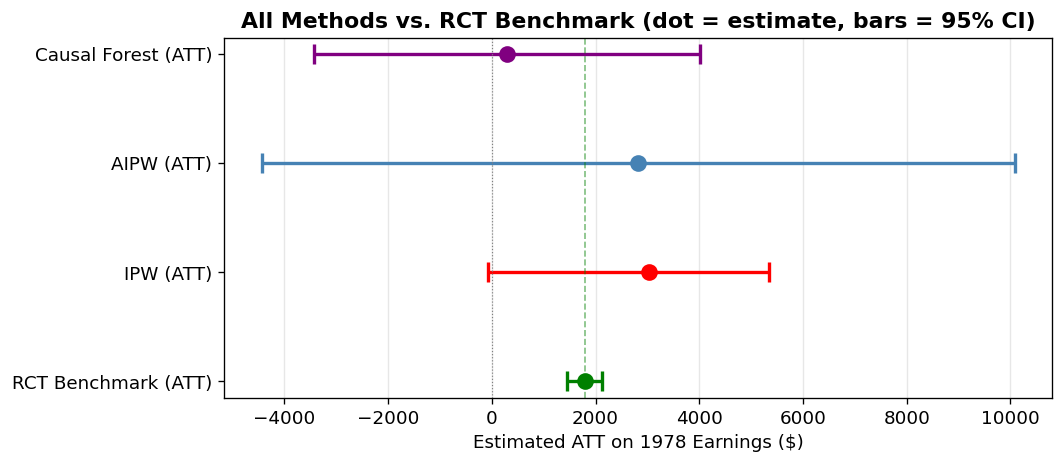

Method                         ATT      CI Lo      CI Hi       Bias  In RCT CI?
------------------------------------------------------------------------------
  RCT Benchmark (ATT)    $   1,794  $   1,457  $   2,131  $      +0  Yes
  IPW (ATT)              $   3,038  $     -63  $   5,348  $  +1,244  No
  AIPW (ATT)             $   2,824  $  -4,436  $  10,083  $  +1,030  No
  Causal Forest (ATT)    $     303  $  -3,418  $   4,024  $  -1,491  No


In [14]:
methods   = ['RCT Benchmark (ATT)', 'IPW (ATT)', 'AIPW (ATT)',  'Causal Forest (ATT)']
estimates = [RCT_BENCHMARK,           att_ipw,    att_aipw,     att_cf]
lowers    = [1457,                    ipw_lo,     aipw_lo,      att_cf_lo]
uppers    = [2131,                    ipw_hi,     aipw_hi,      att_cf_hi]
colors    = ['green',                 'red',      'steelblue',  'purple']

fig, ax = plt.subplots(figsize=(9, 4))
for i, (m, e, lo, hi, c) in enumerate(zip(methods, estimates, lowers, uppers, colors)):
    ax.errorbar(e, i, xerr=[[e-lo],[hi-e]],
                fmt='o', color=c, capsize=6, capthick=2, elinewidth=2, markersize=9)
ax.axvline(RCT_BENCHMARK, color='green', linestyle='--', linewidth=1, alpha=0.5)
ax.axvline(0, color='gray', linewidth=0.7, linestyle=':')
ax.set_yticks(range(len(methods))); ax.set_yticklabels(methods)
ax.set_xlabel('Estimated ATT on 1978 Earnings ($)')
ax.set_title('All Methods vs. RCT Benchmark (dot = estimate, bars = 95% CI)', fontweight='bold')
ax.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.savefig('../outputs/results_comparison.png', bbox_inches='tight')
plt.show()

print(f"{'Method':<24} {'ATT':>9}  {'CI Lo':>9}  {'CI Hi':>9}  {'Bias':>9}  In RCT CI?")
print("-" * 78)
for m, e, lo, hi in zip(methods, estimates, lowers, uppers):
    bias  = e - RCT_BENCHMARK
    check = "Yes" if 1457 <= e <= 2131 else "No"
    print(f"  {m:<22} ${e:>8,.0f}  ${lo:>8,.0f}  ${hi:>8,.0f}  ${bias:>+8,.0f}  {check}")

## 7. Refutation Tests

Three DoWhy-style refutation tests on the AIPW estimate:
1. **Placebo treatment** — shuffled treatment should yield ATE near zero
2. **Data subset** — re-estimate on 80% subsamples to check stability
3. **Unobserved confounder** — sensitivity curve showing how strong hidden confounding must be to nullify the result

In [15]:
# Compact AIPW-ATT function for refutation loops.
# Uses GBM propensity + tighter clip + ATT score. No Crump trim — the
# refutation tests need the full sample so that permuted-treatment scenarios
# (placebo, sensitivity) remain estimable when the PS signal collapses.
def run_aipw(X, T, Y, K=5, seed=42, clip_lo=0.05, clip_hi=0.95):
    n   = len(Y)
    mu0 = np.zeros(n); ps = np.zeros(n)
    kf  = KFold(n_splits=K, shuffle=True, random_state=seed)
    xp  = dict(n_estimators=200, max_depth=4, learning_rate=0.08,
               subsample=0.8, colsample_bytree=0.8, random_state=seed, verbosity=0)
    for tr, val in kf.split(X):
        psm = GradientBoostingClassifier(
            n_estimators=200, max_depth=3, learning_rate=0.08,
            subsample=0.8, random_state=seed).fit(X[tr], T[tr])
        ps[val] = psm.predict_proba(X[val])[:, 1]
        m_ = (T[tr] == 0)
        m  = xgb.XGBRegressor(**xp); m.fit(X[tr][m_], Y[tr][m_])
        mu0[val] = m.predict(X[val])
    ps_c = np.clip(ps, clip_lo, clip_hi)
    p_T  = T.mean()
    if p_T == 0 or p_T == 1:
        return np.nan, np.nan
    phi  = (T * (Y - mu0) / p_T
            - (1 - T) * ps_c * (Y - mu0) / ((1 - ps_c) * p_T))
    return phi.mean(), phi.std() / np.sqrt(n)

X = df[COVARIATES].values
T = df[TREATMENT].values.astype(float)
Y = df[OUTCOME].values
n = len(Y)

Test 1: Placebo treatment (100 permutations)...


  25/100 done


  50/100 done


  75/100 done


  100/100 done


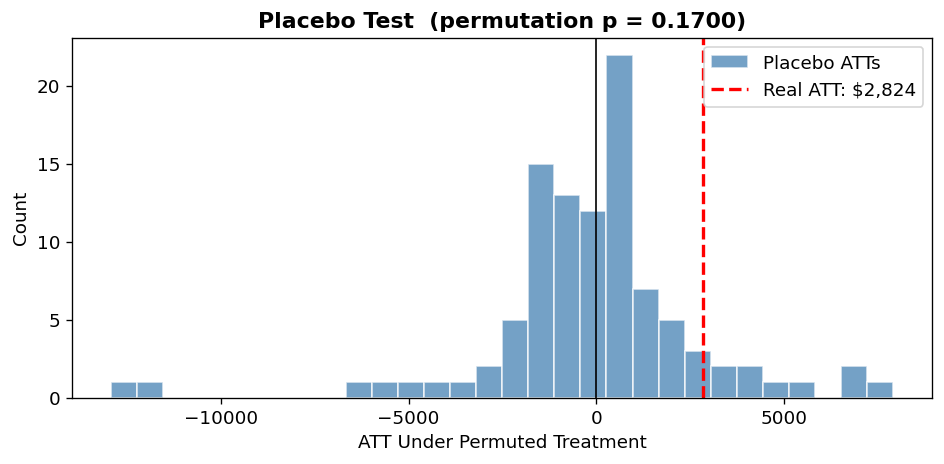

Placebo mean: $-135  SD: $2,909  p = 0.1700


In [16]:
# ── Test 1: Placebo treatment ─────────────────────────────────────────────────
print("Test 1: Placebo treatment (100 permutations)...")
np.random.seed(0)
placebo_atts = []
for i in range(100):
    a, _ = run_aipw(X, np.random.permutation(T), Y, K=3, seed=i)
    placebo_atts.append(a)
    if (i+1) % 25 == 0: print(f"  {i+1}/100 done")

placebo_atts = np.array(placebo_atts)
p_value = (np.abs(placebo_atts) >= np.abs(att_aipw)).mean()

fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(placebo_atts, bins=30, color='steelblue', alpha=0.75, edgecolor='white',
        label='Placebo ATTs')
ax.axvline(att_aipw, color='red', linestyle='--', linewidth=2,
           label=f'Real ATT: ${att_aipw:,.0f}')
ax.axvline(0, color='black', linewidth=1)
ax.set_xlabel('ATT Under Permuted Treatment')
ax.set_ylabel('Count')
ax.set_title(f'Placebo Test  (permutation p = {p_value:.4f})', fontweight='bold')
ax.legend()
plt.tight_layout()
plt.savefig('../outputs/refute_placebo.png', bbox_inches='tight')
plt.show()

print(f"Placebo mean: ${placebo_atts.mean():,.0f}  SD: ${placebo_atts.std():,.0f}  p = {p_value:.4f}")

Test 2: Data subset stability (50 x 80% subsamples)...


  10/50 done


  20/50 done


  30/50 done


  40/50 done


  50/50 done


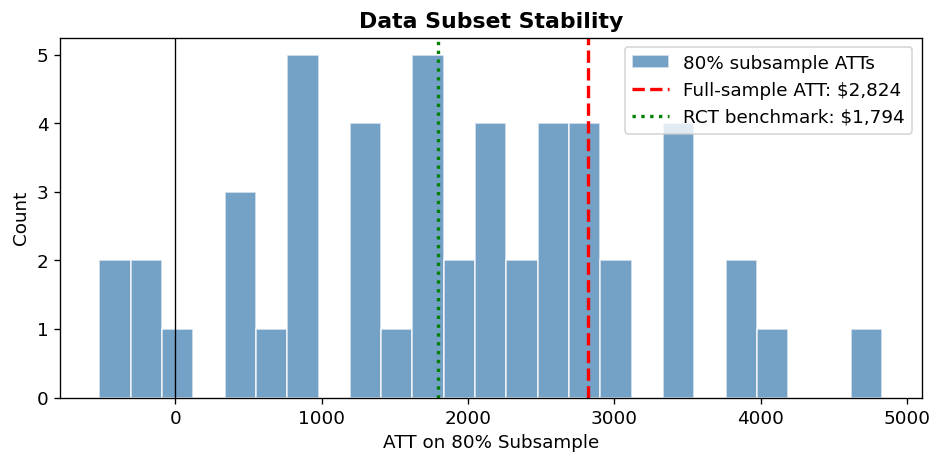

Subsample mean: $1,895  SD: $1,241  % positive: 92%


In [17]:
# ── Test 2: Data subset stability ─────────────────────────────────────────────
print("Test 2: Data subset stability (50 x 80% subsamples)...")
np.random.seed(1)
subset_atts = []
for i in range(50):
    idx   = np.random.choice(n, size=int(n * 0.80), replace=False)
    a, _  = run_aipw(X[idx], T[idx], Y[idx], K=5, seed=i)
    subset_atts.append(a)
    if (i+1) % 10 == 0: print(f"  {i+1}/50 done")

subset_atts = np.array(subset_atts)

fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(subset_atts, bins=25, color='steelblue', alpha=0.75, edgecolor='white',
        label='80% subsample ATTs')
ax.axvline(att_aipw,      color='red',   linestyle='--', linewidth=2,
           label=f'Full-sample ATT: ${att_aipw:,.0f}')
ax.axvline(RCT_BENCHMARK, color='green', linestyle=':',  linewidth=2,
           label=f'RCT benchmark: ${RCT_BENCHMARK:,}')
ax.axvline(0, color='black', linewidth=0.8)
ax.set_xlabel('ATT on 80% Subsample')
ax.set_ylabel('Count')
ax.set_title('Data Subset Stability', fontweight='bold')
ax.legend()
plt.tight_layout()
plt.savefig('../outputs/refute_subset.png', bbox_inches='tight')
plt.show()

print(f"Subsample mean: ${subset_atts.mean():,.0f}  SD: ${subset_atts.std():,.0f}  "
      f"% positive: {(subset_atts > 0).mean():.0%}")

Test 3: Unobserved confounder sensitivity...


  gamma=0.00  ATT=$1,843


  gamma=0.09  ATT=$2,006


  gamma=0.18  ATT=$2,482


  gamma=0.27  ATT=$2,299


...

  gamma=0.64  ATT=$2,890


  gamma=0.73  ATT=$6,654


  gamma=0.82  ATT=$6,011


  gamma=0.91  ATT=$9,096


  gamma=1.00  ATT=$9,337


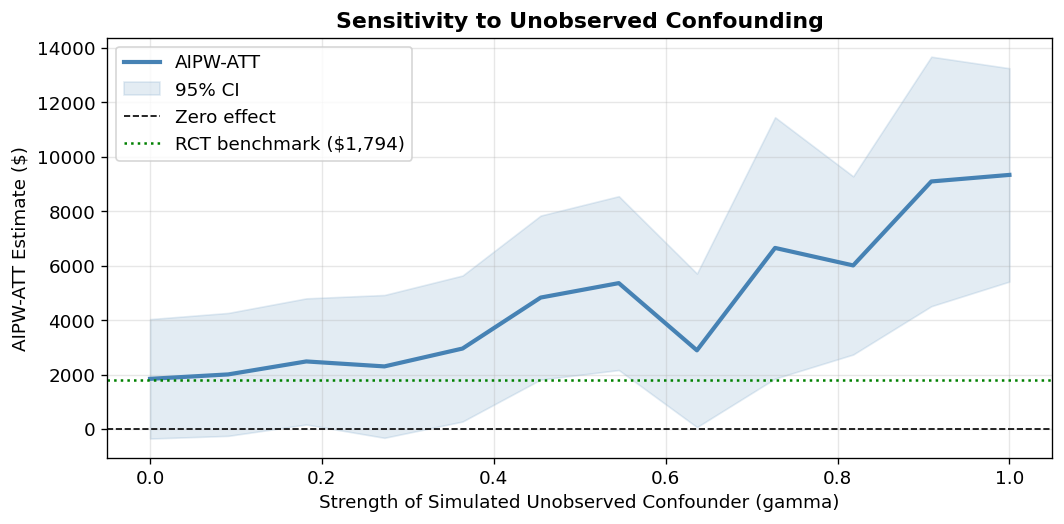

In [18]:
# ── Test 3: Unobserved confounder sensitivity curve ───────────────────────────
print("Test 3: Unobserved confounder sensitivity...")
gammas    = np.linspace(0, 1.0, 12)
sens_atts = []; sens_lo = []; sens_hi = []
Y_sd = Y.std()
np.random.seed(2)

for gamma in gammas:
    U      = (gamma*(T-T.mean()) + np.random.normal(0, 0.5, n) > 0).astype(float)
    Y_conf = Y + gamma * Y_sd * (U - U.mean())
    a, se  = run_aipw(X, T, Y_conf, K=3, seed=42)
    sens_atts.append(a); sens_lo.append(a - 1.96*se); sens_hi.append(a + 1.96*se)
    print(f"  gamma={gamma:.2f}  ATT=${a:,.0f}")

sens_atts = np.array(sens_atts)
sens_lo   = np.array(sens_lo)
sens_hi   = np.array(sens_hi)

fig, ax = plt.subplots(figsize=(9, 4.5))
ax.plot(gammas, sens_atts, color='steelblue', linewidth=2.5, label='AIPW-ATT')
ax.fill_between(gammas, sens_lo, sens_hi, alpha=0.15, color='steelblue', label='95% CI')
ax.axhline(0,             color='black', linewidth=1,   linestyle='--', label='Zero effect')
ax.axhline(RCT_BENCHMARK, color='green', linewidth=1.5, linestyle=':',
           label=f'RCT benchmark (${RCT_BENCHMARK:,})')
ax.set_xlabel('Strength of Simulated Unobserved Confounder (gamma)')
ax.set_ylabel('AIPW-ATT Estimate ($)')
ax.set_title('Sensitivity to Unobserved Confounding', fontweight='bold')
ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('../outputs/refute_sensitivity.png', bbox_inches='tight')
plt.show()

---
## References

- LaLonde, R.J. (1986). Evaluating the econometric evaluations of training programs. *AER*, 76(4), 604–620.
- Dehejia, R.H., & Wahba, S. (1999). Causal effects in nonexperimental studies. *JASA*, 94(448), 1053–1062.
- Wager, S., & Athey, S. (2018). Estimation and inference of heterogeneous treatment effects. *JASA*, 113(523), 1228–1242.
- Sharma, A., & Kiciman, E. (2020). DoWhy: An end-to-end library for causal inference. arXiv:2011.04216.
- Kennedy, E.H. (2020). Optimal doubly robust estimation of heterogeneous causal effects. arXiv:2004.14497.